In [ ]:
import requests

url = "https://huggingface.co/datasets/almanach/hc3_french_ood/resolve/main/data.tar.gz"
headers = {"Authorization": f"Bearer {token}"}
output_filename = "data.tar.gz"

print(f"⏳ Downloading {output_filename}...")
response = requests.get(url, headers=headers)

with open(output_filename, "wb") as f:
    f.write(response.content)

print(f"✅ Downloaded! Now unzip '{output_filename}' manually.")

⏳ Downloading data.tar.gz...
✅ Downloaded! Now unzip 'data.tar.gz' manually.


In [ ]:
import tarfile
import os

output_dir = "french_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

with tarfile.open("data.tar.gz", "r:gz") as tar:
    print(f"📦 Extracting all files to '{output_dir}'...")
    tar.extractall(path=output_dir)
    print("✅ Extraction complete!")

📦 Extracting all files to 'french_data'...


/tmp/ipykernel_6086/3920166153.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=output_dir)


✅ Extraction complete!


In [ ]:
# Change this to "french_data/train_sentence_examples.jsonl" if it's in a subfolder
file_path = "/content/french_data/data/hc3_fr/train_sentence_examples.json"

# 2. Read the file
# We use read_ndjson because each line is a valid JSON object
df_fr_sentences = pl.read_ndjson(file_path)

# 3. Quick Check: See what the columns are
print("📊 Dataset Preview:")
print(df_fr_sentences.head())
print(f"\nAvailable columns: {df_fr_sentences.columns}")

📊 Dataset Preview:
shape: (5, 6)
┌──────┬──────────┬────────┬──────────┬─────────────┬─────────────────────────────────┐
│ id   ┆ entry_id ┆ source ┆ is_human ┆ sentence_id ┆ text                            │
│ ---  ┆ ---      ┆ ---    ┆ ---      ┆ ---         ┆ ---                             │
│ str  ┆ i64      ┆ str    ┆ bool     ┆ i64         ┆ str                             │
╞══════╪══════════╪════════╪══════════╪═════════════╪═════════════════════════════════╡
│ 1602 ┆ 0        ┆ reddit ┆ true     ┆ 0           ┆ PAL et NTSC étaient des méthod… │
│ 1602 ┆ 0        ┆ reddit ┆ true     ┆ 1           ┆ L'Europe utilise de l'électric… │
│ 1602 ┆ 0        ┆ reddit ┆ true     ┆ 2           ┆ Étant donné que le signal anal… │
│ 1602 ┆ 0        ┆ reddit ┆ true     ┆ 3           ┆ Avec les premiers écrans d'ord… │
│ 1602 ┆ 0        ┆ reddit ┆ true     ┆ 4           ┆ Une fois que VGA est arrivé, c… │
└──────┴──────────┴────────┴──────────┴─────────────┴─────────────────────────────────┘

In [ ]:
source_counts = df_fr_sentences["is_human"].value_counts()

In [ ]:
source_counts

is_human,count
bool,u32
true,301819
false,163066


In [ ]:
advanced_separator_regex = r"([-=_*]\s?){5,}"

df_fr_clean = df_fr_sentences.with_columns(
    pl.col("text")
    # 1. Remove HTML
    .str.replace_all(r"<[^>]*>", " ")
    # 2. Remove the spaced-out separators like "- - - -" or "-------"
    .str.replace_all(advanced_separator_regex, " ")
    # 3. Remove Markdown symbols
    .str.replace_all(r"(\*|_|#|`|\[.*?\]\(.*?\))", "")
    # 4. Clean up result (collapse spaces)
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
)

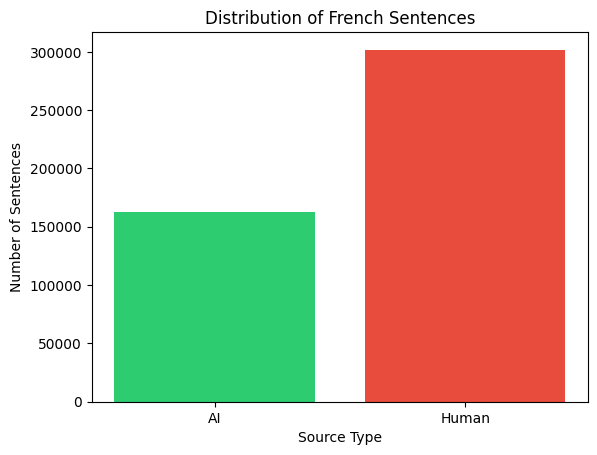

In [ ]:
import matplotlib.pyplot as plt

# Your plotting code
plt.bar(x=source_counts["is_human"], height=source_counts["count"], color=['#e74c3c', '#2ecc71'])

# Set the labels manually
# [0, 1] are the positions, ["AI", "Human"] are the names
plt.xticks([0, 1], ["AI", "Human"])

plt.xlabel("Source Type")
plt.ylabel("Number of Sentences")
plt.title("Distribution of French Sentences")
plt.show()

In [ ]:
import polars as pl

# Direct link to the parquet file on Hugging Face
url = "https://huggingface.co/datasets/angeluriot/french_instruct/resolve/main/dataset.parquet"

# Polars can read directly from HTTPS URLs
df = pl.read_parquet(url)

print("✅ Dataset Loaded Successfully!")
print(df.head())

# Check the distribution of 'style' or 'source' to see the AI/Human mix
if "source" in df.columns:
    print("\n📊 Data Sources:")
    print(df["source"].value_counts())

✅ Dataset Loaded Successfully!
shape: (5, 6)
┌─────────┬─────────────────────────────────┬─────────┬─────────┬───────┬──────────────────────────┐
│ context ┆ conversation                    ┆ author  ┆ style   ┆ code  ┆ source                   │
│ ---     ┆ ---                             ┆ ---     ┆ ---     ┆ ---   ┆ ---                      │
│ str     ┆ list[struct[2]]                 ┆ str     ┆ str     ┆ bool  ┆ str                      │
╞═════════╪═════════════════════════════════╪═════════╪═════════╪═══════╪══════════════════════════╡
│         ┆ [{"user","Traduisez la déducti… ┆ chatbot ┆ chatbot ┆ false ┆ Logic Inference OA       │
│         ┆                                 ┆         ┆         ┆       ┆ (translated…             │
│         ┆ [{"user","Allons-nous un jour … ┆ human   ┆ human   ┆ false ┆ Human ChatGPT Comparison │
│         ┆                                 ┆         ┆         ┆       ┆ Corpu…                   │
│         ┆ [{"user","Considérons les hypo… ┆ 

In [ ]:
import polars as pl

# 1. Explode and Unnest the conversation list
df_flat = (
    df.explode("conversation")
    .unnest("conversation")
)

# 2. Extract AI Essays (Author: chatbot + Role: assistant)
df_ai = (
    df_flat.filter(
        (pl.col("author") == "chatbot") &
        (pl.col("role") == "assistant")
    )
    .select([
        pl.col("text").alias("text_clean"),
        pl.lit(1).alias("label")
    ])
)

# 3. Extract Human Essays (Author: human + Role: assistant)
# Note: In 'human' conversations, the assistant is often a human expert or a high-quality human response
df_human = (
    df_flat.filter(
        (pl.col("author") == "human") &
        (pl.col("role") == "assistant")
    )
    .select([
        pl.col("text").alias("text_clean"),
        pl.lit(0).alias("label")
    ])
)

# 4. Combine and Filter for Long-form (Essays)
# We want texts long enough to be considered an essay (> 150 words)
df_french_essays = (
    pl.concat([df_ai, df_human])
    .filter(pl.col("text_clean").str.split(" ").list.len() > 150)
    .with_columns(
        pl.col("text_clean").str.replace_all(r"\s+", " ").str.strip_chars()
    )
)

print(f"📊 Final French Essay Dataset:")
print(df_french_essays["label"].value_counts())
print(f"Total rows: {len(df_french_essays)}")

📊 Final French Essay Dataset:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i32   ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 73312 │
│ 0     ┆ 20859 │
└───────┴───────┘
Total rows: 94171


In [ ]:
import polars as pl

# Updated Separator Regex:
# Matches a dash, equal sign, or asterisk...
# followed by an optional space...
# repeated 5 or more times.
advanced_separator_regex = r"([-=_*]\s?){5,}"

df_final_clean = df_french_essays.with_columns(
    pl.col("text_clean")
    # 1. Remove HTML
    .str.replace_all(r"<[^>]*>", " ")
    # 2. Remove the spaced-out separators like "- - - -" or "-------"
    .str.replace_all(advanced_separator_regex, " ")
    # 3. Remove Markdown symbols
    .str.replace_all(r"(\*|_|#|`|\[.*?\]\(.*?\))", "")
    # 4. Clean up result (collapse spaces)
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
)

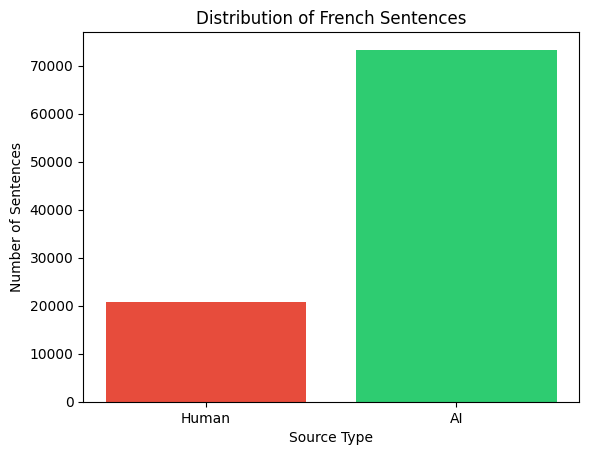

In [ ]:
import matplotlib.pyplot as plt
source_counts = df_final_clean["label"].value_counts()
# Your plotting code
plt.bar(x=source_counts["label"], height=source_counts["count"], color=['#e74c3c', '#2ecc71'])

# Set the labels manually
# [0, 1] are the positions, ["AI", "Human"] are the names
plt.xticks([1, 0], ["AI", "Human"])

plt.xlabel("Source Type")
plt.ylabel("Number of Sentences")
plt.title("Distribution of French Sentences")
plt.show()

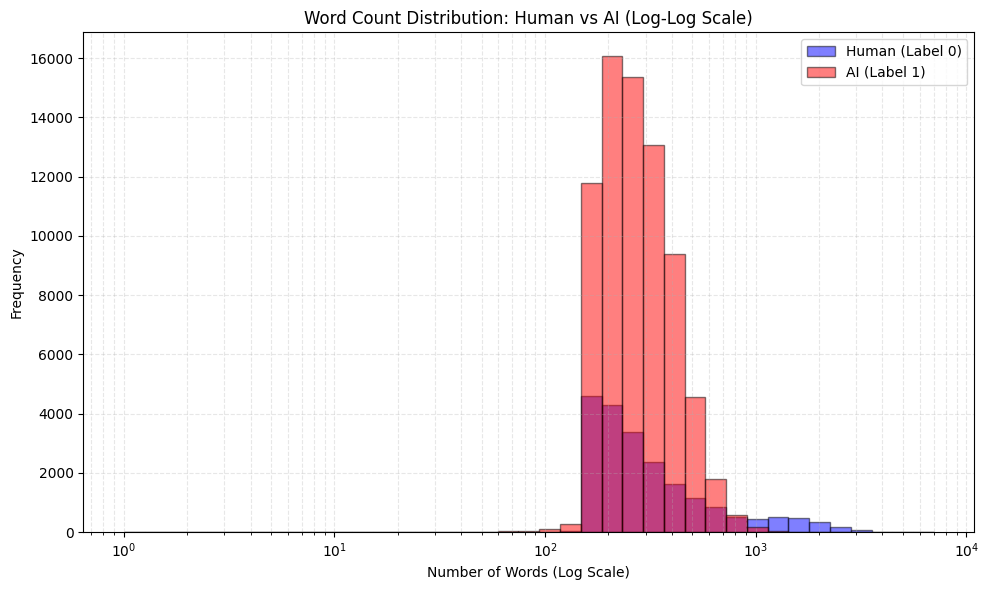

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate word counts
df_viz = df_final_clean.with_columns(
    pl.col("text_clean").str.split(" ").list.len().alias("word_count")
)

# 2. Separate data
ai_counts = df_viz.filter(pl.col("label") == 1)["word_count"].to_numpy()
human_counts = df_viz.filter(pl.col("label") == 0)["word_count"].to_numpy()

# 3. Create Log-Spaced Bins
# This ensures bins look equal width on a log-scale X-axis
min_val = df_viz["word_count"].min()
max_val = df_viz["word_count"].max()
# 40 bins from the smallest to the largest word count, spaced logarithmically
bins = np.logspace(np.log10(min_val), np.log10(max_val), 40)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms
ax.hist(human_counts, bins=bins, alpha=0.5, label='Human (Label 0)',
        color='blue', edgecolor='black')

ax.hist(ai_counts, bins=bins, alpha=0.5, label='AI (Label 1)',
        color='red', edgecolor='black')

# --- THE LOG SCALE APPLICATION ---
ax.set_xscale('log') # Logarithmic Word Counts

# Formatting
ax.set_title("Word Count Distribution: Human vs AI (Log-Log Scale)")
ax.set_xlabel("Number of Words (Log Scale)")
ax.set_ylabel("Frequency")
ax.legend(loc='upper right')
ax.grid(True, which="both", ls="--", alpha=0.3)

# 5. Save the result
plt.tight_layout()
plt.savefig("word_count_distribution_log_log.png")

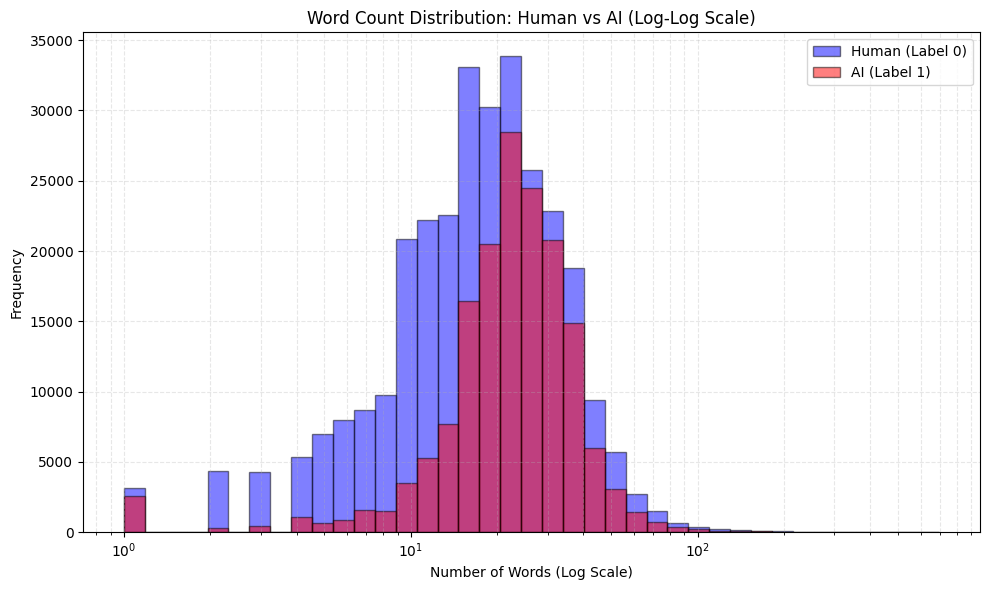

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate word counts
df_viz = df_fr_clean.with_columns(
    pl.col("text").str.split(" ").list.len().alias("word_count")
)

# 2. Separate data
ai_counts = df_viz.filter(pl.col("is_human") == False)["word_count"].to_numpy()
human_counts = df_viz.filter(pl.col("is_human") == True)["word_count"].to_numpy()

# 3. Create Log-Spaced Bins
# This ensures bins look equal width on a log-scale X-axis
min_val = df_viz["word_count"].min()
max_val = df_viz["word_count"].max()
# 40 bins from the smallest to the largest word count, spaced logarithmically
bins = np.logspace(np.log10(min_val), np.log10(max_val), 40)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms
ax.hist(human_counts, bins=bins, alpha=0.5, label='Human (Label 0)',
        color='blue', edgecolor='black')

ax.hist(ai_counts, bins=bins, alpha=0.5, label='AI (Label 1)',
        color='red', edgecolor='black')

# --- THE LOG SCALE APPLICATION ---
ax.set_xscale('log') # Logarithmic Word Counts

# Formatting
ax.set_title("Word Count Distribution: Human vs AI (Log-Log Scale)")
ax.set_xlabel("Number of Words (Log Scale)")
ax.set_ylabel("Frequency")
ax.legend(loc='upper right')
ax.grid(True, which="both", ls="--", alpha=0.3)

# 5. Save the result
plt.tight_layout()
plt.savefig("word_count_distribution_log_log_1.png")

Although the second dataset has a huge gap in word-count frequencies between AI and Humans, mixing the two remains safe. This is because the first corpus is significantly larger in volume and contains a higher proportion of human text. Since the model prioritizes the patterns in the largest part of the data, the balanced word-counts of the first corpus will 'anchor' the training. This forces the model to ignore length as a shortcut (frequency leak) and instead focus on the actual writing style.

In [ ]:
# Change this to "french_data/train_sentence_examples.jsonl" if it's in a subfolder
file_path = "/content/french_data/data/hc3_fr/test_sentence_examples.json"

# 2. Read the file
# We use read_ndjson because each line is a valid JSON object
df_fr_test_sentences = pl.read_ndjson(file_path)

# 3. Quick Check: See what the columns are
print("📊 Dataset Preview:")
print(df_fr_test_sentences.head())
print(f"\nAvailable columns: {df_fr_test_sentences.columns}")

📊 Dataset Preview:
shape: (5, 6)
┌──────┬──────────┬────────┬──────────┬─────────────┬─────────────────────────────────┐
│ id   ┆ entry_id ┆ source ┆ is_human ┆ sentence_id ┆ text                            │
│ ---  ┆ ---      ┆ ---    ┆ ---      ┆ ---         ┆ ---                             │
│ i64  ┆ i64      ┆ str    ┆ bool     ┆ i64         ┆ str                             │
╞══════╪══════════╪════════╪══════════╪═════════════╪═════════════════════════════════╡
│ 3648 ┆ 0        ┆ reddit ┆ true     ┆ 0           ┆ La nature est venue en premier… │
│ 3648 ┆ 1        ┆ reddit ┆ true     ┆ 0           ┆ Il n'y a pas de cercle dans la… │
│ 3648 ┆ 1        ┆ reddit ┆ true     ┆ 1           ┆ la nature ne fait rien.         │
│ 3648 ┆ 1        ┆ reddit ┆ true     ┆ 2           ┆ Et Pi n'a pas besoin d'être "r… │
│ 3648 ┆ 1        ┆ reddit ┆ true     ┆ 3           ┆ Il n'y a vraiment rien à résou… │
└──────┴──────────┴────────┴──────────┴─────────────┴─────────────────────────────────┘

In [ ]:
advanced_separator_regex = r"([-=_*]\s?){5,}"

df_fr_test_clean = df_fr_test_sentences.with_columns(
    pl.col("text")
    # 1. Remove HTML
    .str.replace_all(r"<[^>]*>", " ")
    # 2. Remove the spaced-out separators like "- - - -" or "-------"
    .str.replace_all(advanced_separator_regex, " ")
    # 3. Remove Markdown symbols
    .str.replace_all(r"(\*|_|#|`|\[.*?\]\(.*?\))", "")
    # 4. Clean up result (collapse spaces)
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
)

In [ ]:
df_second = df_final_clean.sample(fraction=1.0, shuffle=True, seed=42)
test_size = int(len(df_second) * 0.1)
df_test_2 = df_second.head(test_size)
df_train_part2 = df_second.tail(-test_size)

In [ ]:
df_fr_clean = df_fr_clean.with_columns(
    pl.when(pl.col("is_human") == True)
    .then(0)
    .otherwise(1)
    .alias("label")
)

In [ ]:
df_train = df_fr_clean.select([
    pl.col("text"),
    pl.col("label"),
    ])


In [ ]:
df_train

text,label
str,i32
"""PAL et NTSC étaient des méthod…",0
"""L'Europe utilise de l'électric…",0
"""Étant donné que le signal anal…",0
"""Avec les premiers écrans d'ord…",0
"""Une fois que VGA est arrivé, c…",0
…,…
"""Il est possible que votre peti…",1
"""Il est important que votre pet…",1
"""Le prestataire sera en mesure …",1


In [ ]:
df_fr_test_clean = df_fr_test_clean.with_columns(
    pl.when(pl.col("is_human") == True)
    .then(0)
    .otherwise(1)
    .alias("label")
)

In [ ]:
df_test = df_fr_test_clean.select([
    pl.col("text"),
    pl.col("label"),
    ])

In [ ]:
df_train_2 = df_train_part2.select([
    pl.col("text_clean").alias("text"),
    pl.col("label")
]
)

In [ ]:
df_train_2

text,label
str,i32
"""Sûr ! Le vent est le mouvement…",1
"""Lorsque vous injectez un liqui…",1
"""Étape 1. Comprendre la signifi…",0
"""Un chef de projet idéal devrai…",1
"""Un euphémisme est un terme ou …",1
…,…
"""Transpirer et se sentir chaud …",1
"""Le code PHP ci-dessus utilise …",1
"""Le coefficient de corrélation …",1


In [ ]:
df_test2 = df_test_2.select([
    pl.col("text_clean").alias("text"),
    pl.col("label")
]
)

In [ ]:
train_ds = pl.concat([df_train,df_train_2])

In [ ]:
test_ds = pl.concat([df_test,df_test2])

In [ ]:
train_ds.write_parquet("fr_train.parquet")
test_ds.write_parquet("fr_test.parquet")